# 01. DNN 기초 - Fashion-MNIST와 LFW 얼굴 인식

이 노트북에서 다루는 것:

1. **Fashion-MNIST DNN** - 완전연결 신경망의 기본 구조를 만들고, **과적합(overfitting)이 일어나는 장면을 직접 관찰**한다.
2. **LFW 얼굴 인식** - 과적합을 막는 `EarlyStopping`, 불균형 데이터를 위한 `stratify`, 그리고 `confusion_matrix`로 결과를 뜯어본다.

핵심 질문 세 가지:
- 픽셀을 왜 255로 나누는가? (그리고 **항상** 나눠야 하는가?)
- 학습을 오래 하면 항상 좋아지는가?
- 정확도 하나로 모델을 평가해도 되는가?

## 1부. Fashion-MNIST

### 1-1. 데이터 불러오기

Fashion-MNIST는 28x28 흑백 의류 이미지 7만 장(학습 6만 / 테스트 1만)이다.
10개 클래스: 티셔츠, 바지, 풀오버, 드레스, 코트, 샌들, 셔츠, 스니커즈, 가방, 앵클부츠.

MNIST(손글씨 숫자)와 크기·형식이 완전히 같아서 **바로 갈아끼울 수 있지만, 훨씬 어렵다.**
뒤에서 같은 구조의 모델로 두 데이터를 비교하면 그 차이가 드러난다.

In [1]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print(x_train.shape, y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)


### 1-2. 데이터를 눈으로 확인하기

모델을 만들기 전에 **데이터를 직접 봐야 한다.** 실행할 때마다 다른 이미지가 나온다.
`y_train[idx]`로 정답 레이블을 함께 출력해서, 이미지와 레이블이 맞는지 확인한다.

9


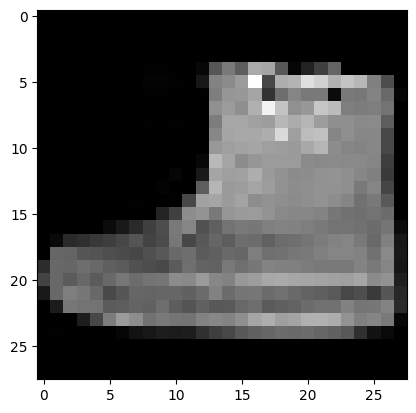

In [2]:
import numpy as np
import matplotlib.pyplot as plt

idx = np.random.randint(60000)
print(y_train[idx])
plt.imshow(x_train[idx], cmap='gray')
plt.show()

### 1-3. 스케일링 - 왜 255로 나누는가?

신경망은 입력값이 **0~1 근처의 작은 값**일 때 학습이 잘 된다.
입력이 0~255처럼 크면 가중치와 곱해진 값이 커져서 기울기가 불안정해진다.

그래서 먼저 **값의 범위를 확인**한다. 습관적으로 255로 나누지 말고, 항상 확인부터 할 것.
(뒤의 LFW 데이터는 이미 0~1이라서 나누면 안 된다 - 그 때 다시 이야기한다.)

In [3]:
np.min(x_train), np.max(x_train)

(np.uint8(0), np.uint8(255))

### 1-4. 전처리 - 펼치기(flatten) + 스케일링

**DNN(완전연결망)은 2차원 이미지를 그대로 받지 못한다.** 28x28을 784짜리 1차원 벡터로 펼쳐야 한다.

이 과정에서 **픽셀의 위치 정보가 사라진다.** 옆에 있던 픽셀이 옆에 있다는 사실을 모델이 알 수 없게 된다.
이게 DNN의 근본적 한계이고, 다음 노트북의 CNN이 해결하려는 문제다.

- `reshape(60000, -1)` : `-1`은 "나머지는 알아서 계산하라" → 28x28 = 784
- `/ 255`: 0\~255 → 0\~1

In [4]:
x_train_1d = x_train.reshape(60000, -1) / 255
x_test_1d = x_test.reshape(10000, -1) / 255
print(x_train_1d.shape, x_test_1d.shape)

(60000, 784) (10000, 784)


### 1-5. 클래스 균형 확인

각 클래스에 데이터가 몇 개씩 있는지 확인한다.
한 클래스가 압도적으로 많으면(불균형), 모델이 "무조건 그 클래스"라고 찍어도 정확도가 높게 나와서 속기 쉽다.

Fashion-MNIST는 테스트셋이 클래스당 정확히 1000개씩 **완벽하게 균형** 잡혀 있다.
(2부의 LFW는 정반대다.)

In [5]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

### 1-6. 레이블 원-핫 인코딩

정답이 `3`(드레스)이라는 정수 하나로 있으면, 모델은 "3은 2보다 크다"는 **엉뚱한 순서 관계**를 학습하려 든다.
클래스는 크기 비교가 무의미하므로, 각 클래스를 독립된 축으로 만든다.

`3` → `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

출력층의 `softmax` + `categorical_crossentropy` 조합은 이 원-핫 형태를 전제로 한다.

In [6]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)
print(y_train_oh.shape, y_test_oh.shape)

(60000, 10) (10000, 10)


### 1-7. 모델 만들기 - 그리고 과적합을 관찰하기

```
Input(784) → Dense(256, relu) → Dense(64, relu) → Dense(10, softmax)
```

- **`relu`** : 은닉층의 기본 활성화 함수. 음수는 0으로, 양수는 그대로.
- **`softmax`** : 출력층에서 10개 값을 합이 1인 확률 분포로 만든다.
- **`categorical_crossentropy`** : 원-핫 정답과 softmax 확률의 차이를 재는 손실 함수.
- 총 파라미터: **218,058개**

**이번에는 일부러 콜백 없이 50에폭을 끝까지 돌린다.** 무슨 일이 벌어지는지 보기 위해서다.

`validation_data`로 테스트셋을 넘겨서, 학습 데이터와 처음 보는 데이터에서의 성능을 **동시에** 추적한다.

> CPU 기준 몇 분 걸린다. Colab에서 GPU 런타임(런타임 → 런타임 유형 변경)을 켜면 훨씬 빠르다.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hist = model.fit(x_train_1d, y_train_oh, epochs=50, validation_data=(x_test_1d, y_test_oh))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8265 - loss: 0.4918 - val_accuracy: 0.8452 - val_loss: 0.4351
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8664 - loss: 0.3635 - val_accuracy: 0.8617 - val_loss: 0.3776
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8784 - loss: 0.3296 - val_accuracy: 0.8617 - val_loss: 0.3787
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8875 - loss: 0.3027 - val_accuracy: 0.8660 - val_loss: 0.3745
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8939 - loss: 0.2868 - val_accuracy: 0.8736 - val_loss: 0.3534
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8980 - loss: 0.2735 - val_accuracy: 0.8768 - val_loss: 0.3473
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9022 - loss: 0.2588 - val_accuracy: 0.8677 - val_loss: 0.3692
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9058 - loss: 0.2509 - 

### 1-8. 학습 곡선 - 과적합의 정체

`hist.history`에 에폭별 손실과 정확도가 기록되어 있다. 학습 손실과 검증 손실을 함께 그려본다.

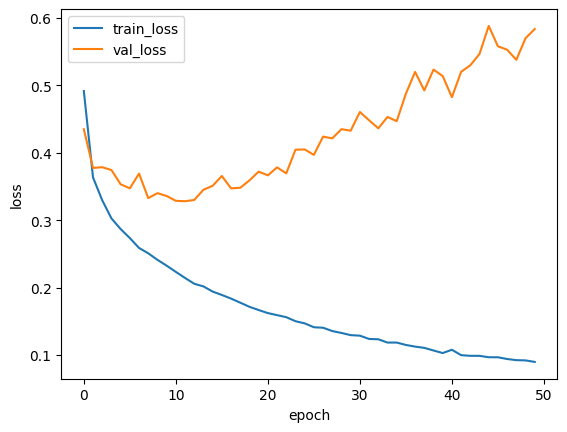

In [8]:
plt.plot(hist.history['loss'], label='train_loss')
plt.plot(hist.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### 1-9. 무슨 일이 일어났는가 ★ 이 노트북의 핵심

실행 결과:

| | 학습 정확도 | 학습 손실 | **검증** 정확도 | **검증** 손실 |
|---|---|---|---|---|
| 에폭 1 | 0.8265 | 0.4918 | 0.8452 | **0.4351** |
| 에폭 12 | 0.9186 | 0.2143 | 0.8892 | **0.3282** ← 최저점 |
| 에폭 50 | 0.9652 | 0.0897 | 0.8929 | **0.5838** ← 다시 올라감 |

**학습 손실은 계속 떨어졌다** (0.4918 → 0.0897). 모델은 열심히 배우고 있다.
**그런데 검증 손실은 12에폭에서 바닥(0.3282)을 찍고 다시 올라갔다** (→ 0.5838, 약 1.8배).

이게 **과적합(overfitting)** 이다. 모델이 학습 데이터를 *외우기* 시작하면서,
처음 보는 데이터에 대한 성능은 오히려 나빠진 것이다. 위 그래프에서 두 곡선이 벌어지는 지점이 바로 그 순간이다.

즉 **12에폭에서 멈췄어야 했다.** 나머지 38에폭은 모델을 더 나쁘게 만드는 데 쓰였다.

> ⚠️ 검증 *정확도*는 0.8892 → 0.8929로 **오히려 조금 올랐다**(최고는 29에폭의 0.8957).
> 손실은 1.8배로 나빠졌는데 정확도는 멀쩡해 보인다.
> **정확도만 보면 과적합을 놓친다.** 손실(loss)이 훨씬 예민한 지표다.
>
> 왜 그럴까? 정확도는 "제일 큰 값이 정답인가"만 따진다. 반면 손실은 **얼마나 확신했는가**까지 본다.
> 과적합된 모델은 맞힐 땐 여전히 맞히지만, **틀릴 때 훨씬 더 강하게 확신하며 틀린다.**
> 그 대가가 손실에 잡히는 것이다. (다음 노트북에서 이 "확신에 찬 오답"의 극단적 사례를 본다.)

그럼 "언제 멈춰야 하는지"를 어떻게 알 수 있을까? 2부에서 `EarlyStopping`이 이 문제를 해결한다.

---
## 2부. LFW 얼굴 인식

### 2-1. 데이터 불러오기

**LFW(Labeled Faces in the Wild)** — 유명인 얼굴 사진 데이터셋. sklearn이 자동으로 내려받는다.

`min_faces_per_person=100` : 사진이 100장 이상인 인물만 남긴다 → 5명, 총 1140장.

1부와 달라지는 세 가지를 눈여겨볼 것:
1. 픽셀 범위가 **이미 0~1** (255로 나누면 안 된다)
2. 클래스가 **심하게 불균형**
3. 데이터가 1140장뿐이라 **train/test를 직접 나눠야** 한다

> 첫 실행 시 약 200MB를 다운로드하므로 시간이 좀 걸린다.


(1140, 62, 47)
['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']


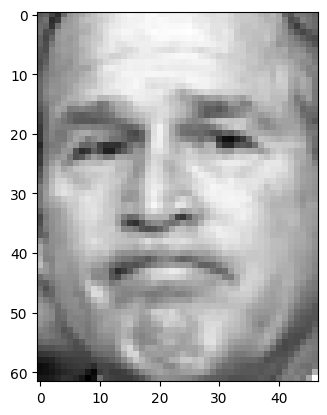

In [9]:
from sklearn.datasets import fetch_lfw_people

data = fetch_lfw_people(min_faces_per_person=100)
print(data.images.shape)
print(data.target_names)
plt.imshow(data.images[0], cmap='gray')
plt.show()

### 2-2. 스케일링 확인 — 여기서는 255로 나누면 안 된다 ★

1부에서와 똑같이 값의 범위부터 확인한다. **결과가 다르다.**


In [11]:
np.min(data.images), np.max(data.images)

(np.float32(0.0), np.float32(1.0))

### 2-3. 전처리 — 펼치기만, 나누지는 않기

sklearn이 제공하는 LFW는 이미 float32 0.0~1.0 범위다.
여기서 습관적으로 `/255`를 하면 값이 0\~0.004가 되어 **모델이 아무것도 학습하지 못한다.**

> **교훈: 전처리는 데이터마다 다르다. 확인하고 나서 결정하라.**

62×47 = 2914 → 1차원으로 펼친다.


In [12]:
x_data = data.images.reshape(1140, -1)
y_data = to_categorical(data.target)
print(x_data.shape, y_data.shape)


(1140, 2914) (1140, 5)


### 2-4. 클래스 불균형 확인

1부의 Fashion-MNIST는 클래스마다 1000개씩 완벽히 균형 잡혀 있었다. LFW는 어떨까?


In [13]:
np.unique(data.target, return_counts=True)

(array([0, 1, 2, 3, 4]), array([236, 121, 530, 109, 144]))

### 2-5. 데이터 분할 — `stratify`가 필요한 이유 ★

1140장을 학습용/테스트용으로 나눠야 한다. 그냥 무작위로 자르면?

Bush가 46%, Schroeder가 9.5%다. 운이 나쁘면 테스트셋에 Schroeder가 거의 안 들어갈 수 있고,
그러면 **그 클래스의 성능을 측정할 방법이 없어진다.**

`stratify=y_data` : **원본의 클래스 비율을 학습셋과 테스트셋 양쪽에 그대로 유지**하며 나눈다.
불균형 데이터에서는 사실상 필수다.

`random_state` : 난수 시드. 같은 값을 주면 매번 같은 분할이 나와 **결과가 재현된다.**
`test_size`를 지정하지 않으면 기본값 0.25 → 학습 855장 / 테스트 285장.


In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data,
    stratify=y_data,
    random_state=260710
)
print(x_train.shape, y_test.shape)


(855, 2914) (285, 5)


### 2-6. EarlyStopping — 1부의 과적합 문제를 해결하기 ★

1부에서 "12에폭에서 멈췄어야 했다"는 걸 **사후에야** 알았다.
**EarlyStopping은 그 판단을 학습 중에 자동으로 해준다.**

- `monitor='val_loss'` : 검증 손실을 감시한다. (정확도가 아니라 손실! 1부의 교훈)
- `patience=10` : 검증 손실이 10에폭 연속으로 개선되지 않으면 학습을 멈춘다.
  - 손실은 들쭉날쭉하므로 한 번 나빠졌다고 바로 멈추면 안 된다. 그래서 "참을성"이 필요하다.
- **`restore_best_weights=True`** : ← **원본 수업 코드에 없던 옵션이다. 반드시 넣자.**
  - 이게 없으면, patience 동안 나빠진 **마지막 시점의 가중치**가 그대로 남는다.
  - 즉 "최고점에서 10에폭 더 망가진 모델"을 손에 쥐게 된다.
  - `True`로 두면 검증 손실이 가장 낮았던 시점의 가중치로 **되돌려 준다.**

모델 구조는 입력이 커진 만큼(2914) 첫 층도 키웠다:
```
Input(2914) → Dense(1024) → Dense(256) → Dense(64) → Dense(5, softmax)
```
총 파라미터 **3,264,133개** (1부의 15배).

---

**실행 결과 — EarlyStopping이 실제로 작동했다:**

| | 학습 정확도 | 학습 손실 | **검증** 정확도 | **검증** 손실 |
|---|---|---|---|---|
| 에폭 1 | 0.3977 | 1.8170 | 0.4667 | 1.4675 |
| **에폭 22** | 0.8515 | 0.4411 | **0.8351** | **0.4684** ← 최저점 |
| 에폭 32 (마지막) | 0.8491 | 0.4318 | 0.7684 | 0.6161 |

- 22에폭에서 검증 손실이 최저(0.4684)를 찍었다.
- 이후 10에폭(patience) 동안 개선이 없어서 **32에폭에서 자동으로 멈췄다.** 50에폭을 다 돌지 않았다.
- 그 10에폭 동안 검증 정확도는 **0.8351 → 0.7684로 떨어지고** 있었다. 계속 뒀으면 더 나빠졌을 것이다.
- **`restore_best_weights=True` 덕분에**, 학습이 끝난 시점의 `model`은 32에폭짜리 망가진 모델이 아니라
  **22에폭의 최적 가중치**를 담고 있다. 아래 혼동 행렬은 그 모델로 예측한 결과다.

> 이 옵션이 없었다면 우리는 val_acc 0.7684짜리 모델로 평가했을 것이다.
> 한 줄 차이로 **6.7%p**가 갈렸다.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

esc = EarlyStopping(monitor='val_loss',
                    patience=10,
                    restore_best_weights=True)

model = Sequential()
model.add(Input(shape=(2914,)))
model.add(Dense(1024, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(5, activation='softmax'))
model.summary()

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

hist = model.fit(x_train, y_train,
                 validation_data=(x_test, y_test),
                 epochs=50,
                 callbacks=[esc])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1024)           │     2,984,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,264,133 (12.45 MB)

 Trainable params: 3,264,133 (12.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.3977 - loss: 1.8170 - val_accuracy: 0.4667 - val_loss: 1.4675
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4702 - loss: 1.4193 - val_accuracy: 0.4667 - val_loss: 1.4248
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4830 - loss: 1.3916 - val_accuracy: 0.5123 - val_loss: 1.3159
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5064 - loss: 1.2919 - val_accuracy: 0.5228 - val_loss: 1.2764
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5298 - loss: 1.2843 - val_accuracy: 0.4912 - val_loss: 1.3413
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5193 - loss: 1.2927 - val_accuracy: 0.5474 - val_loss: 1.2032
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5520 - loss: 1.1499 - val_accuracy: 0.5860 - val_loss: 1.1043
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5591 - loss: 1.1027 - val_accuracy: 0.6105 - val_los

### 2-7. 혼동 행렬 — 정확도 뒤에 숨은 것 ★

복원된 최적 모델의 검증 정확도는 **0.8351**. **그런데 이 숫자 하나로는 모델을 알 수 없다.**

Bush가 데이터의 46%였다는 걸 기억하자. 모델이 **"무조건 Bush"라고만 답해도 46%는 맞힌다.**
83.5%가 정말 5명을 골고루 잘 맞힌 결과인지, 아니면 Bush만 잘 맞히고 나머지는 엉망인지 구분해야 한다.

**혼동 행렬(confusion matrix)** 은 "실제 A인데 B라고 예측한 개수"를 표로 보여준다.
- **행 = 실제 정답, 열 = 모델의 예측**
- **대각선 = 맞힌 것**, 대각선 밖 = 틀린 것 (어디로 틀렸는지까지 보인다)

`argmax(axis=1)`로 원-핫 벡터를 다시 정수 레이블로 되돌린 뒤 넘긴다.

In [16]:
from sklearn.metrics import confusion_matrix

pred = model.predict(x_test)
cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(pred, axis=1))
print(data.target_names)
print(cm)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']
[[ 54   0   2   0   3]
 [  7  22   1   0   0]
 [  5   5 117   2   4]
 [  0   1   3  14   9]
 [  2   0   2   1  31]]


### 2-8. 결과 읽기

실행 결과 (행=실제, 열=예측):

```
                     Powell  Rumsfeld  Bush  Schroeder  Blair    합계
Colin Powell      [[   54,        0,     2,        0,     3 ]     59
Donald Rumsfeld    [    7,       22,     1,        0,     0 ]     30
George W Bush      [    5,        5,   117,        2,     4 ]    133
Gerhard Schroeder  [    0,        1,     3,       14,     9 ]     27
Tony Blair         [    2,        0,     2,        1,    31 ]]    36
```

대각선 합계 = 54+22+117+14+31 = **238 / 285 = 83.5%**

표를 읽으면 정확도 숫자 하나에는 없던 것이 보인다:

- **Schroeder(4행)가 압도적으로 취약하다.** 27장 중 **14장만 맞혔다(52%)** — 거의 동전 던지기다.
  그리고 **9장을 Blair로 착각**했다. 학습 데이터가 109장으로 가장 적었던 인물이다.
- **Bush(3행)는 133장 중 117장(88%)** 으로 가장 잘 맞힌다. 데이터가 530장으로 가장 많았으니 당연하다.
- **Rumsfeld(2행)** 는 30장 중 22장(73%), 그중 **7장을 Powell로 착각**했다.
- 즉 **데이터가 적은 인물일수록 성능이 나쁘다.** 클래스 불균형의 대가가 여기서 드러난다.

전체 정확도 83.5%만 보면 "그럭저럭 괜찮네" 싶지만,
실제로는 **Bush를 잘 맞혀서 평균이 올라간 것**이고 Schroeder는 절반밖에 못 맞힌다.

> **교훈: 정확도는 요약일 뿐이다. 어디서 틀리는지는 혼동 행렬이 알려준다.**
> 불균형 데이터에서 전체 정확도는 다수 클래스의 성능에 가려진다.

---

## 정리

| 배운 것 | 핵심 |
|---|---|
| **스케일링** | 255로 나눌지는 **데이터를 확인하고** 정한다. Fashion-MNIST는 0~255(나눔), LFW는 0~1(안 나눔) |
| **flatten** | DNN은 이미지를 1차원으로 펴야 한다 → **위치 정보가 사라진다** (CNN이 해결할 문제) |
| **과적합** | 학습 손실↓ 인데 검증 손실↑ 이면 외우기 시작한 것. **정확도가 아니라 손실을 보라** |
| **EarlyStopping** | `monitor='val_loss'`, `patience`, 그리고 **`restore_best_weights=True`를 잊지 말 것** |
| **stratify** | 불균형 데이터를 나눌 때 클래스 비율 유지 |
| **혼동 행렬** | 정확도 하나로는 안 보이는 "어떤 클래스에서 틀리는지"를 드러낸다 |

### 이번 실행의 두 장면

1. **Fashion-MNIST (콜백 없음)** — 12에폭이 최적이었는데 50에폭을 다 돌려서 val_loss가 0.3282 → 0.5838로 나빠졌다. *과적합을 방치한 경우.*
2. **LFW (EarlyStopping)** — 22에폭이 최적이었고, 32에폭에서 자동으로 멈춘 뒤 22에폭 가중치를 복원했다. *과적합을 막은 경우.*

같은 함정, 다른 결말. 1번을 겪었기 때문에 2번의 콜백이 왜 필요한지 알 수 있다.

**다음 노트북(02)** 에서는 이 DNN을 실제 데이터에 적용할 때 만나는 두 가지 함정을 본다:
직접 그린 이미지를 넣었더니 **확률 1.0으로 확신하며 틀리는** 현상, 그리고 데이터 12장으로 1000만 파라미터 모델을 학습하면 벌어지는 일.